# 19회차 기출문제 해답

## 문제 1

**Data description**

시험과 비슷한 데이터입니다.

-   Attrition_flag : target variable, 이탈 고객인지 유무
-   Gender: 성별
-   customer age : 고객의 나이
-   income category : 고객이 속한 소득 범주
-   card category : 고객이 갖고 있는 카드 범주
-   credit limit : 카드 한도
-   total revolving balance : 다음달로 이월되는 미지급 금액
-   average utilization ratio : 사용 한도와 비교해서 사용 중인 금액의 비율
-   avg open to buy : 특정 고객에게 할당된 평균 사용 가능 금액
-   month inactive 12 mon : 신용카드를 사용할 때 비활성 금액

In [1]:
import pandas as pd 
import numpy as np 
import time
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, plot_roc_curve, roc_auc_score, roc_curve, f1_score
from sklearn import set_config
set_config(display="diagram")

In [2]:
dat = pd.read_csv("problem1.csv")

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   attrition_flag          10127 non-null  object 
 1   gender                  10127 non-null  object 
 2   customer_age            10127 non-null  int64  
 3   income_category         10127 non-null  object 
 4   card_category           10127 non-null  object 
 5   credit_limit            10127 non-null  float64
 6   total_revolving_bal     10127 non-null  int64  
 7   avg_utilization_ratio   10127 non-null  float64
 8   avg_open_to_buy         10127 non-null  float64
 9   months_inactive_12_mon  10127 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 791.3+ KB


In [4]:
y = dat['attrition_flag']
X = dat.drop(['attrition_flag'], axis = 1)

**1. EDA를 실시하시오(시각화 포함)(5점).**

In [5]:
pd.options.display.max_columns = None # full 출력 옵션 
X.describe();

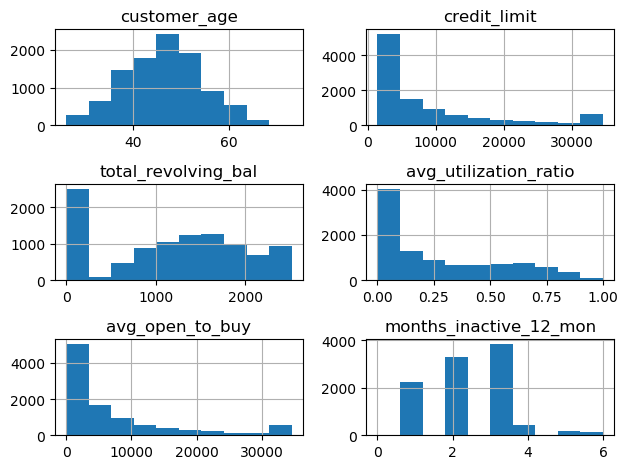

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
X.hist();
plt.tight_layout();
plt.show();

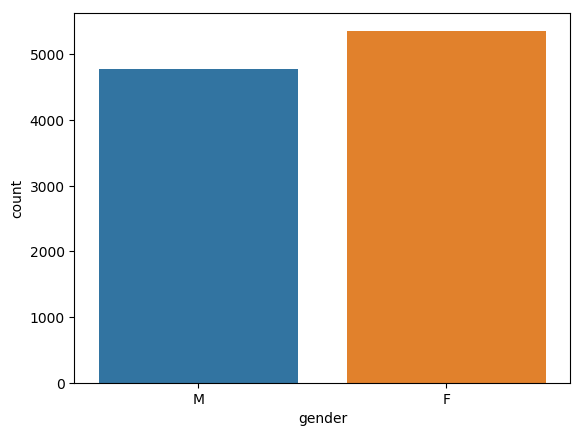

In [7]:
X.select_dtypes('object').columns

sns.countplot(X['gender']);
plt.show();

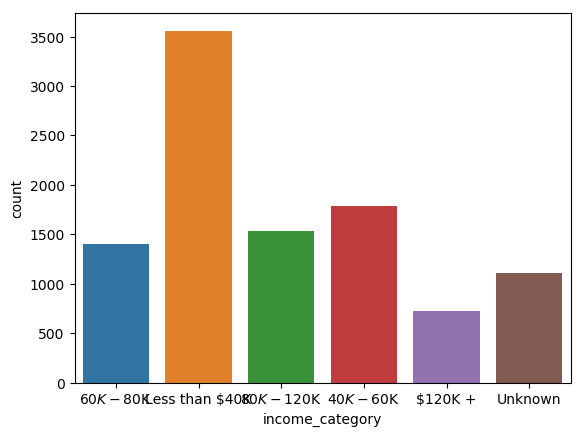

In [8]:
sns.countplot(X['income_category']);
plt.show();

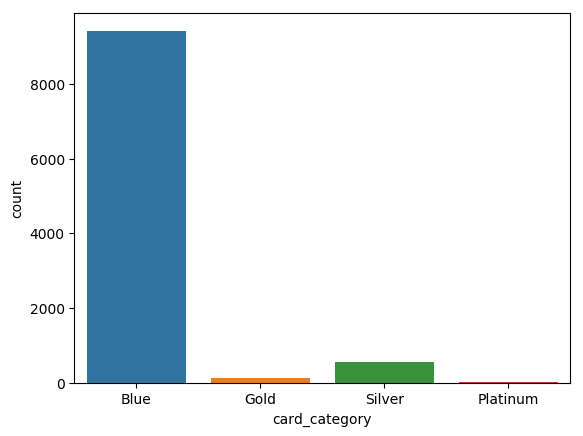

In [9]:
sns.countplot(X['card_category']);
plt.show();

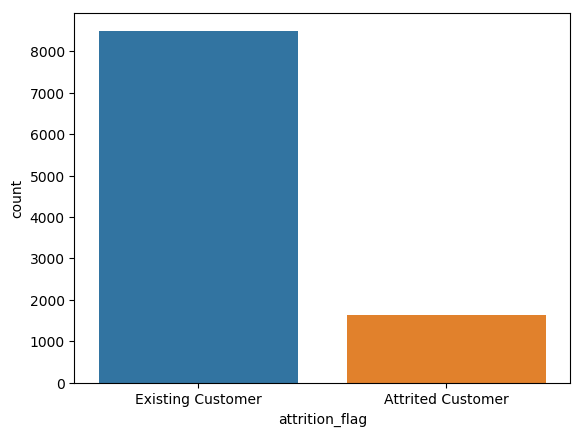

In [10]:
sns.countplot(y);
plt.show();

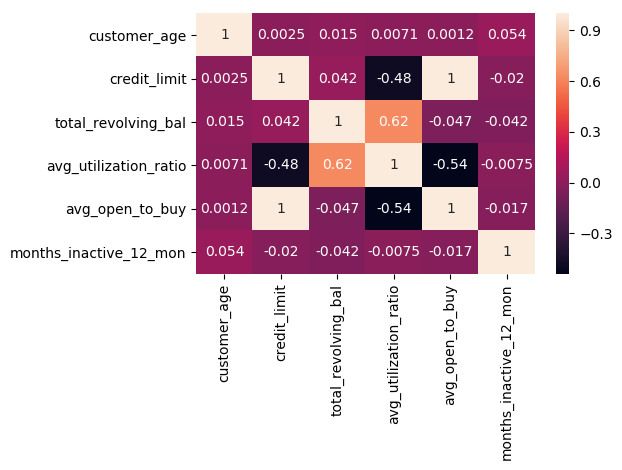

In [11]:
corr = X.select_dtypes('number').corr()
sns.heatmap(corr, annot = True);
plt.tight_layout();
plt.show();

EDA 해석 생략

**2. 모형을 적합하시오(15점).**

-   train/test 7:3 분할
-   분류모형 3개 적합
-   confusion matrix 출력

훈련 데이터와 테스트 데이터를 7:3으로 분할한다. attrition_flag 변수의 경우 클래스 불균형이 존재하므로, 층화 샘플링을 적용한다.


In [12]:
from sklearn.model_selection import train_test_split
dat = dat.assign(attrition_flag = np.where(dat['attrition_flag'] == 'Attrited Customer', 1, 0))
y = dat['attrition_flag']
X = dat.drop(['attrition_flag'], axis = 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, stratify = dat['attrition_flag'], random_state = 0)

범주형 변수에 대해서 원핫 인코딩을 진행하고, 연속형 변수에 대해서 표준화를 진행한다.


In [13]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
num_columns = train_X.select_dtypes('number').columns
cat_columns = train_X.select_dtypes('object').columns

num_pipe = Pipeline([("scaler", StandardScaler())])

cat_pipe = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer(
    [("num_process", num_pipe, num_columns), 
    ("cat_process", cat_pipe, cat_columns)]
    , remainder='passthrough'
)

모델 튜닝은 파라미터의 범위를 제한하여 진행하였으며, 반복 5-fold 교차검증을 통해 validation 데이터를 여러번 생성 후 적합하여, 하이퍼파라미터별 모형 성능을 교차 검증하였다.

**Random forest**

In [14]:
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestClassifier
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

pipe_rf = Pipeline(
    [
        ("preprocess", preprocess),
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", RandomForestClassifier())
    ]
)

RandomForest_param = {'classifier__max_features': np.arange(0.5, 1, 0.1)}

start_time = time.time()
RandomForest_search = GridSearchCV(estimator = pipe_rf, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
RandomForest_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('RandomForest best score : ', RandomForest_search.best_score_)

56.081828117370605s
RandomForest best score :  0.6526054585338853


**Decision tree**

In [15]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline(
    [
        ("preprocess", preprocess),
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", DecisionTreeClassifier())
    ]
)

decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

start_time = time.time()
decisiontree_search = GridSearchCV(estimator = pipe_dt, 
                      param_grid = decisiontree_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
decisiontree_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('decision tree best score : ', decisiontree_search.best_score_)

2.8959953784942627s
decision tree best score :  0.5


**XGBOOST**

In [16]:
import xgboost as xgb

pipe_xgb = Pipeline(
    [
        ("preprocess", preprocess),
        ("oversampling", RandomOverSampler(sampling_strategy='minority')),
        ("classifier", xgb.XGBClassifier()) # y label 수치형이어야 함
    ]
)

Xgb_param = {'classifier__learning_rate': np.arange(0.01, 0.3, 0.05)}

start_time = time.time()
xgb_search = GridSearchCV(estimator = pipe_xgb, 
                      param_grid = Xgb_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
xgb_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

print('XGBOOST best score : ', xgb_search.best_score_)

24.23702359199524s
XGBOOST best score :  0.7602545053127433


balanced accuracy 비교 결과 XGBOOST 모형을 선택한다. 최종 테스트 데이터에서의 성능은 다음과 같다. 

In [17]:
pred_xgb = xgb_search.predict(test_X)
print(classification_report(test_y, pred_xgb))
print(balanced_accuracy_score(test_y, pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1701
           1       0.43      0.77      0.55       325

    accuracy                           0.80      2026
   macro avg       0.69      0.79      0.71      2026
weighted avg       0.86      0.80      0.82      2026

0.7865065798399131


**3. 위에서 실시한 분류 모형 3개를 앙상블하여 예측하고 result.csv로 파일 제출(30점)**

::: callout-note
하드 보팅 or 소프트 보팅 중 선택하면 됩니다.
:::

**Averaging(soft voting)**

예측 확률값을 평균 내서 최종 앙상블 결과로 산출한다.

In [18]:
result = pd.DataFrame({'rf_prob' : RandomForest_search.predict_proba(test_X)[:, 0],
                       'dt_prob' : decisiontree_search.predict_proba(test_X)[:, 0],
                       'xgb_prob' : xgb_search.predict_proba(test_X)[:, 0]})
                       
result['average'] = (result.rf_prob + result.dt_prob + result.xgb_prob)/3

result['pred'] = np.where(result.average > 0.5, 0, 1)
result

print(classification_report(test_y, result.pred))
print(balanced_accuracy_score(test_y, result.pred))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1701
           1       0.47      0.62      0.54       325

    accuracy                           0.83      2026
   macro avg       0.70      0.74      0.72      2026
weighted avg       0.85      0.83      0.84      2026

0.7446316646316646


**Voting(hard voting)**

다수결 투표에 의해 최종 예측값을 산출한다.

In [19]:
pred_dt = decisiontree_search.predict(test_X)
pred_rf = RandomForest_search.predict(test_X)


result2 = pd.DataFrame({'rf_pred' : pred_rf,
                       'dt_pred' : pred_dt,
                       'xgb_pred' : pred_xgb})
                       
result2['pred'] = np.where((result2.rf_pred == 0) & (result2.dt_pred == 0), 0,
                          np.where((result2.rf_pred == 0) & (result2.xgb_pred == 0), 0,
                                  np.where((result2.dt_pred == 0) & (result2.xgb_pred == 0), 0, 1)))

print(classification_report(test_y, result2.pred))
print(balanced_accuracy_score(test_y, result2.pred))         

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1701
           1       0.49      0.41      0.45       325

    accuracy                           0.84      2026
   macro avg       0.69      0.66      0.68      2026
weighted avg       0.83      0.84      0.83      2026

0.6640510107176774


**예측 결과 csv 제출**

::: callout-note
시험에 명시된 조건에 맞춰서 predict type = 'raw' or 'prob' 만 구분하여 제출
:::

## 문제 2

**Data description**

강물에 흐름에 관한 데이터입니다.

**1. 시계열 데이터의 정규성과 이분산성을 분석하시오(시각화 포함)(10점).**


In [20]:
dat = pd.read_csv('problem2.csv')
dat.columns = ['value']

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, acf, plot_pacf, pacf
import pmdarima as pm

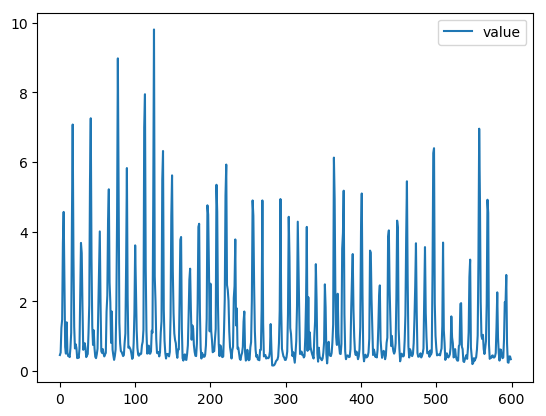

In [22]:
dat.plot();
plt.show();

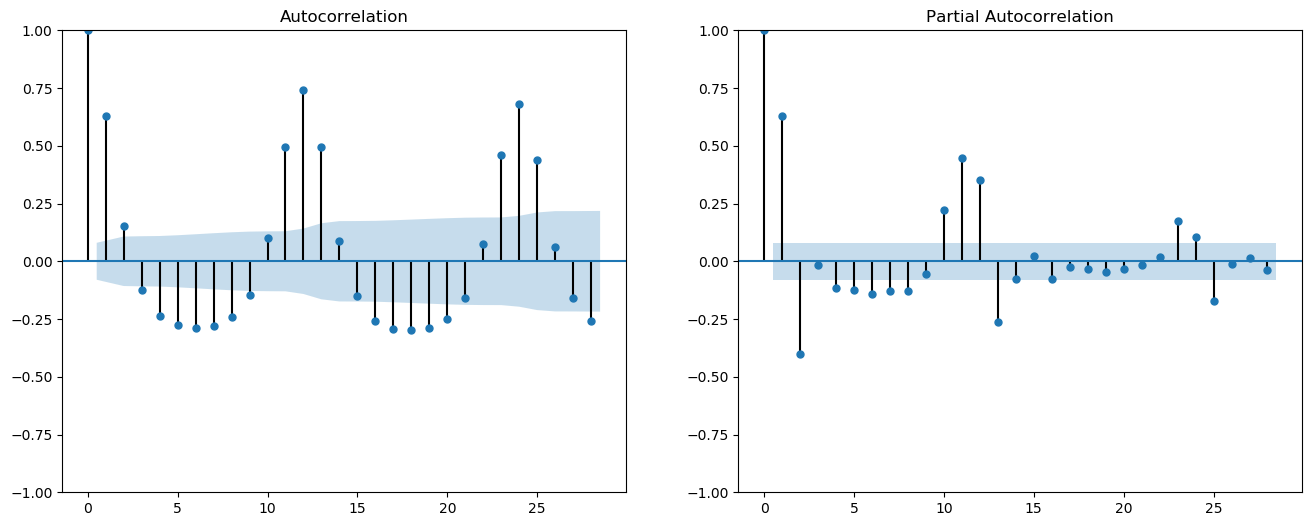

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6));
plot_acf(dat['value'], ax = ax1);
plot_pacf(dat['value'], ax = ax2, method = 'ywm');
plt.show();

추세 그래프와 acf plot을 보면 12를 주기로 acf 값이 커지는 것을 볼 수 있다. 따라서 계절 차분을 고려한다.

**2. 시계열 데이터가 정규성이 아니라면, 고정시계열이 있는지 확인하고 이를 처리하시오(15점).**

In [24]:
from pmdarima.arima.utils import nsdiffs
nsdiffs(dat, m = 12, max_D=12, test='ch')

0

계절 추세 존재 여부 확인 : Canova-Hansen test 결과를 바탕으로 추천된 계절 차분 차수는 0인 것을 확인할 수 있다. 

**계절 차분**

그래프를 통해 계절성을 확인한다. 

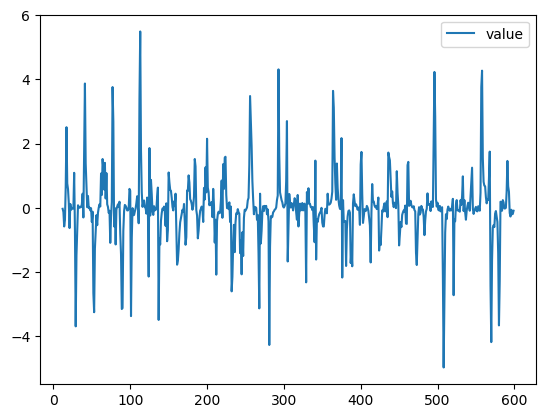

In [25]:
dat_diff2 = dat.diff(12)
dat_diff2.dropna(inplace = True)
dat_diff2.plot();
plt.show();

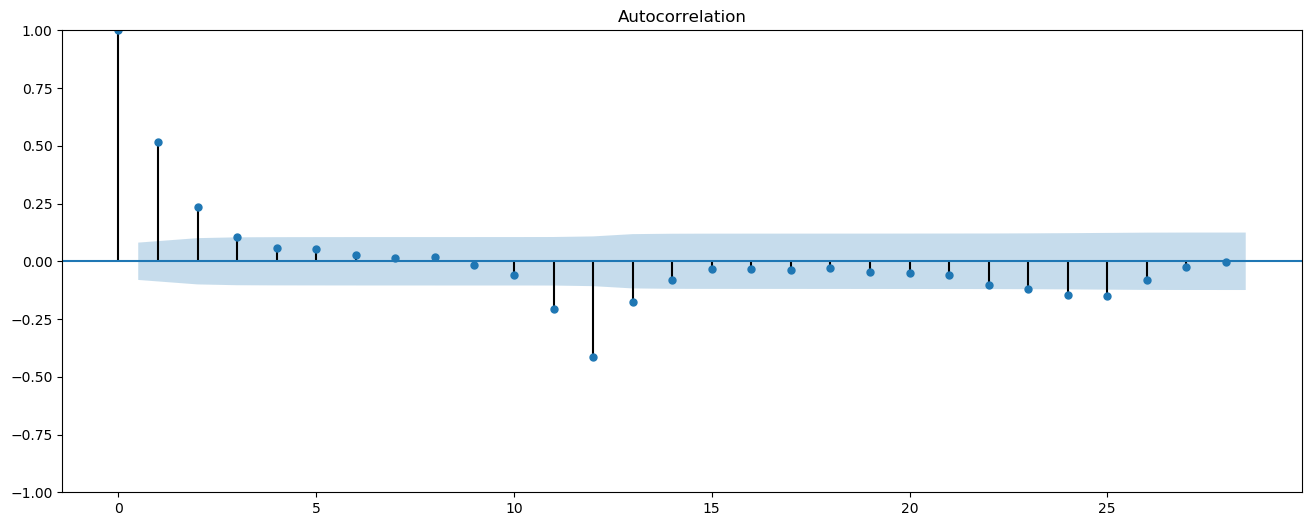

In [26]:
fig, ax1 = plt.subplots(1, 1, figsize=(16,6))
plot_acf(dat_diff2['value'], ax = ax1)
plt.show();

계절 차분을 했을 때 계절 추세가 제거되고, 무작위 변동으로 바뀌었기 때문에 정상성 만족한다.

**3. SARIMA 분석을 실시하고, 여러 파라미터를 적용해보고 최적의 모형을 제시하시오(15점).**

모델 탐색을 위해 auto.arima를 활용한다.

In [27]:
model3 = pm.auto_arima(dat.value, 
                   start_p=0, 
                   start_q=0,
                   max_p=5, 
                   max_q=5,
                   m=12,
                   d=0,  
                   start_P=0, 
                   D=1, 
                   trace=False,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

In [28]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  600
Model:             SARIMAX(1, 0, 0)x(2, 1, [1], 12)   Log Likelihood                -618.946
Date:                              Sun, 20 Jul 2025   AIC                           1249.893
Time:                                      13:54:32   BIC                           1276.153
Sample:                                           0   HQIC                          1260.125
                                              - 600                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0066      0.005     -1.390      0.164      -0.016       0.003
ar.L1          0.5092      0.023     21.964      0.000       0.464       0.555
ar.S.L12       0.0378      0.031      1.229      0.219      -0.022       0.098
ar.S.L24      -0.0601      0.025     -2.403      0.016      -0.109      -0.011
ma.S.L12      -0.8785      0.018    -48.562      0.000      -0.914      -0.843
sigma2         0.4658      0.013     36.248      0.000       0.441       0.491
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):              1541.47
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

aic를 기준으로 ARIMA(1, 0, 0)(1, 1, 2)\_12 모델이 선택된다. 신뢰구간을 통해 계수 유의성을 검토한다.


-   귀무 가설: 해당 계수는 0이다.
-   대립 가설: 해당 계수는 0이 아니다.

계수에 대한 신뢰구간을 확인해본 결과, 유의수준 5%에서 절편, ar.S.L12가 신뢰구간에 0을 포함하므로, 귀무가설을 기각할 수 없다. 따라서 해당 계수는 통계적으로 유의하지 않다.

비유의한 모수를 제거한다.

In [29]:
from statsmodels.tsa.arima.model import ARIMA
model3_1 = ARIMA(dat, order=(1, 0, 0), seasonal_order=([0,1], 1, 1, 12)).fit()
print(model3_1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                value   No. Observations:                  600
Model:             ARIMA(1, 0, 0)x([2], 1, [1], 12)   Log Likelihood                -620.384
Date:                              Sun, 20 Jul 2025   AIC                           1248.768
Time:                                      13:54:33   BIC                           1266.275
Sample:                                           0   HQIC                          1255.589
                                              - 600                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5135      0.023     22.550      0.000       0.469       0.558
ar.S.L24      -0.07

절편과 ar.S.L12 항이 제거된 ARIMA(1,0,0)(2,1,1)\[12\] 잠정 모형 선택한다. 

**4. 위에서 제시한 모델의 잔차와 잡음에 대해 시각화하고 분석하시오(10점).**

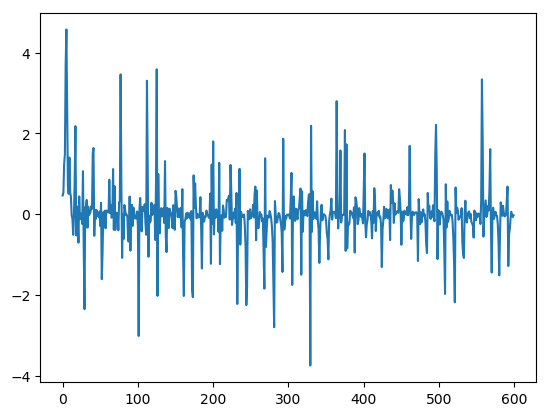

In [30]:
sm.stats.acorr_ljungbox(model3_1.resid, lags=[24])
model3_1.resid.plot();
plt.show();

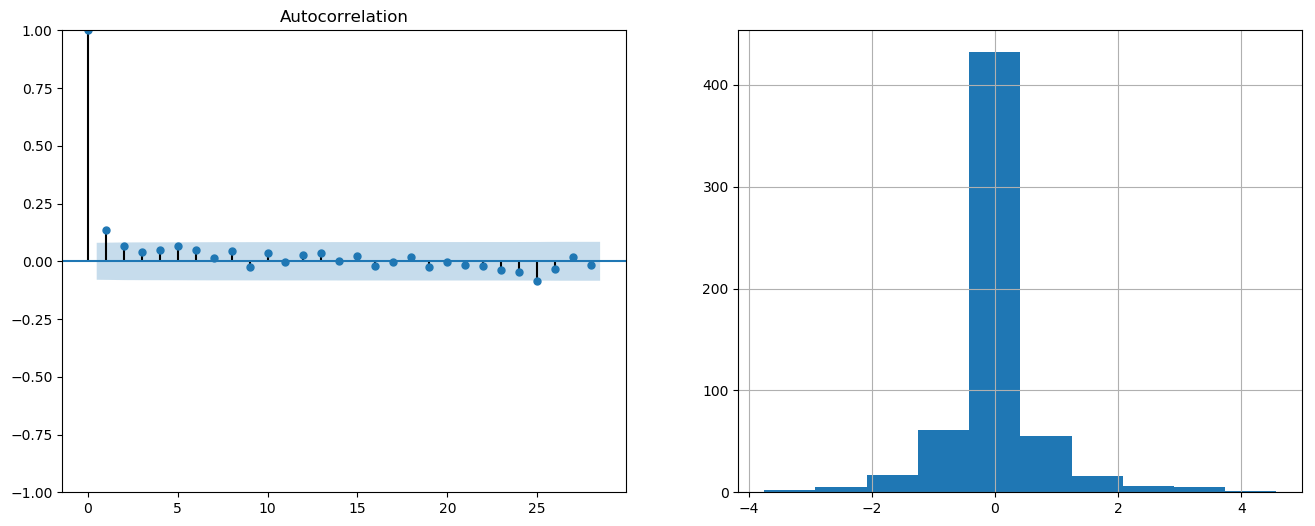

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6));
plot_acf(model3_1.resid, ax = ax1);
model3_1.resid.hist(ax = ax2);
plt.show();

-   귀무 가설 : 잔차 사이에 자기상관이 존재하지 않는다.
-   대립 가설 : 잔차 사이에 자기상관이 존재한다.

ljung box 테스트 결과 유의수준 0.05에서 p-value = 0.274917로 크므로, 귀무가설을 기각할 수 없다. 따라서 잔차 사이에 자기상관이 존재하지 않는다.

잔차의 ACF 그래프를 보면 뚜렷한 분산 증가 감소 혹은 경향성이 없고, 0을 중심으로 무작위로 분포한다.

따라서 잔차는 백색잡음과정을 따른다고 볼 수 있다.

추가적으로 잔차의 분포를 확인했을 때, 근사적으로 정규분포의 형태를 띄므로, 오차의 정규성 가정을 만족한다고 할 수 있다.